# Analysis of Trade and Production

## Contents
#### Import data set
#### Data Check
#### Subset 2014 - 2024
#### Data Overview
#### Production after 2014
- Hypothesis
#### Import of Instruments
#### Export of Instruments
#### Observe and compare Prices
#### Calculate Net Imports
#### Calculate Domestic Market Size
#### Growth
#### Hypothesis on Imports vs. Production
#### Market Share
#### Export Ratio
#### Domestic Demand Total

In [1]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

## Import data set

In [2]:
# path to folder
path = '/Users/susanwang/Documents/Data Projects/DEPianoSales'

In [3]:
# import dataset
df = pd.read_csv(os.path.join(path, 'Data','merged_df.csv'), index_col=False)

## Data Check

In [4]:
df.head()

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,...,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
0,2000,18085,1958,383406,33301,11642,183014,51959.07,26633.53,143484.05,...,2.873048,13.602416,0.374235,1.829487,8.420873,0.196780,NaN,NaN,NaN,NaN
1,2001,16011,2698,251130,30887,11657,224581,45007.36,27005.48,122257.98,...,2.811027,10.009444,0.486831,1.745050,8.373823,0.168021,NaN,NaN,NaN,NaN
2,2002,16974,1920,196482,36038,11765,257098,44334.76,22853.54,113748.07,...,2.611922,11.902885,0.578924,1.724198,8.419635,0.142661,NaN,NaN,NaN,NaN
3,2003,17670,1800,161518,36239,15881,214030,51029.10,22288.04,91423.09,...,2.887895,12.382244,0.566024,1.850545,7.381779,0.176025,NaN,NaN,NaN,NaN
4,2004,10810,1364,107761,22360,13936,107094,36494.82,18486.55,69751.34,...,3.376024,13.553189,0.647278,3.284422,9.471856,0.546361,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,...,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
20,2020,11537,2208,440943,7686,2975,182046,38694.45,30549.08,236836.99,...,3.353944,13.835634,0.537115,6.865653,48.449156,0.843019,28370.0,3282.0,83450.0,1927.0
21,2021,13993,2542,520304,9364,3775,227169,46622.16,35638.68,280894.04,...,3.331820,14.019937,0.539865,7.249808,48.211277,0.749783,32257.0,3532.0,99545.0,2156.0
22,2022,14680,2624,416152,8569,3563,228862,45098.22,33331.35,245157.41,...,3.072086,12.702496,0.589105,6.883521,45.125290,0.760541,36026.0,3627.0,110519.0,2228.0
23,2023,9878,2472,298469,7015,3634,223037,34860.04,33260.13,177312.17,...,3.529059,13.454745,0.594072,7.060557,49.123613,0.763121,29477.0,2410.0,122217.0,2190.0
24,2024,6558,1876,336050,5728,2659,225301,21018.70,25245.36,176079.88,...,3.205047,13.457015,0.523969,6.146720,45.922539,0.727405,18028.0,1336.0,110422.0,1286.0


In [6]:
df.shape

(25, 23)

In [7]:
# summarize NaN rows
df.isna().sum()

Year                           0
Upright Import Quantity        0
Grand Import Quantity          0
Keyboard Import Quantity       0
Upright Export Quantity        0
Grand Export Quantity          0
Keyboard Export Quantity       0
Upright Import Trade Value     0
Grand Import Trade Value       0
Keyboard Import Trade Value    0
Upright Export Trade Value     0
Grand Export Trade Value       0
Keyboard Export Trade Value    0
Upright Import Price           0
Grand Import Price             0
Keyboard Import Price          0
Upright Export Price           0
Grand Export Price             0
Keyboard Export Price          0
Prod Upright Euro              9
Upright Prod Quantity          9
Prod Grand Euro                9
Grand Prod Quantity            9
dtype: int64

For Growth columns, the NaN is at the beginning because it is the first instance, and we cannot compare to a previous year.
For Production columns, there are only consecutive values from 2010 to 2024. Before then, only for 2006. (Missing values for 9 years)

In [8]:
df.dtypes

Year                             int64
Upright Import Quantity          int64
Grand Import Quantity            int64
Keyboard Import Quantity         int64
Upright Export Quantity          int64
Grand Export Quantity            int64
Keyboard Export Quantity         int64
Upright Import Trade Value     float64
Grand Import Trade Value       float64
Keyboard Import Trade Value    float64
Upright Export Trade Value     float64
Grand Export Trade Value       float64
Keyboard Export Trade Value    float64
Upright Import Price           float64
Grand Import Price             float64
Keyboard Import Price          float64
Upright Export Price           float64
Grand Export Price             float64
Keyboard Export Price          float64
Prod Upright Euro              float64
Upright Prod Quantity          float64
Prod Grand Euro                float64
Grand Prod Quantity            float64
dtype: object

Production Quantities should be int64 as well. Convert later, as the present NaN values prevent the column as a whole to be converted.

## Subset to 2014 - 2024

In [9]:
df2014 = df[df['Year'] >= 2014].copy()
df2014.head()

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,...,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
14,2014,14068,2317,254469,10658,3907,121177,47895.19,40926.16,231015.81,...,3.404549,17.663427,0.907835,6.467610,38.924175,1.163625,27201.00,3964.0,74626.00,2563.0
15,2015,12908,2386,262565,8954,3211,127429,40949.44,30494.82,202245.39,...,3.172408,12.780729,0.770268,6.240281,38.133391,0.960420,28637.00,3699.0,74804.00,1996.0
16,2016,14083,2317,297512,8958,2940,132009,45748.83,27243.08,214669.42,...,3.248515,11.757911,0.721549,6.044232,39.153694,0.917371,28796.25,3630.0,79010.25,2022.0
17,2017,11760,2259,302030,8682,3301,152016,37993.50,27959.71,229715.28,...,3.230740,12.377030,0.760571,6.697784,40.410118,0.938470,28955.50,3562.0,83216.50,2049.0
18,2018,12084,2257,324570,8691,3303,150036,36432.04,26928.79,240739.25,...,3.014899,11.931232,0.741718,6.659672,45.746530,1.011101,29114.75,3493.0,87422.75,2075.0


In [10]:
df2014.tail()

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,...,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
20,2020,11537,2208,440943,7686,2975,182046,38694.45,30549.08,236836.99,...,3.353944,13.835634,0.537115,6.865653,48.449156,0.843019,28370.0,3282.0,83450.0,1927.0
21,2021,13993,2542,520304,9364,3775,227169,46622.16,35638.68,280894.04,...,3.331820,14.019937,0.539865,7.249808,48.211277,0.749783,32257.0,3532.0,99545.0,2156.0
22,2022,14680,2624,416152,8569,3563,228862,45098.22,33331.35,245157.41,...,3.072086,12.702496,0.589105,6.883521,45.125290,0.760541,36026.0,3627.0,110519.0,2228.0
23,2023,9878,2472,298469,7015,3634,223037,34860.04,33260.13,177312.17,...,3.529059,13.454745,0.594072,7.060557,49.123613,0.763121,29477.0,2410.0,122217.0,2190.0
24,2024,6558,1876,336050,5728,2659,225301,21018.70,25245.36,176079.88,...,3.205047,13.457015,0.523969,6.146720,45.922539,0.727405,18028.0,1336.0,110422.0,1286.0


In [11]:
df2014.shape

(11, 23)

## Data Overview

In [12]:
pd.set_option('display.max_columns', None)

In [13]:
# overview of most current year 2024
yr2024 = df2014.tail(1)
yr2024

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,Upright Export Trade Value,Grand Export Trade Value,Keyboard Export Trade Value,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
24,2024,6558,1876,336050,5728,2659,225301,21018.7,25245.36,176079.88,35208.41,122108.03,163885.0,3.205047,13.457015,0.523969,6.14672,45.922539,0.727405,18028.0,1336.0,110422.0,1286.0


In [14]:
t_2024 = yr2024.T
t_2024

,24
Year,2024.000000
Upright Import Quantity,6558.000000
Grand Import Quantity,1876.000000
Keyboard Import Quantity,336050.000000
Upright Export Quantity,5728.000000
Grand Export Quantity,2659.000000
Keyboard Export Quantity,225301.000000
Upright Import Trade Value,21018.700000
Grand Import Trade Value,25245.360000
Keyboard Import Trade Value,176079.880000


In [15]:
imports = t_2024[1:4]
print(imports)

exports = t_2024[4:7]
print(exports)

                                24
Upright Import Quantity     6558.0
Grand Import Quantity       1876.0
Keyboard Import Quantity  336050.0
                                24
Upright Export Quantity     5728.0
Grand Export Quantity       2659.0
Keyboard Export Quantity  225301.0


In [16]:
# create color palette to match Canva

colors = ['#bd4a5d', '#8e245a', '#e1785e', '#7d6d67']
print(colors)

sns.set(rc={'axes.facecolor':'#f4f4f4', 'figure.facecolor':'f4f4f4'})

['#bd4a5d', '#8e245a', '#e1785e', '#7d6d67']


In [17]:
matplotlib.rcParams['figure.figsize']

[6.4, 4.8]

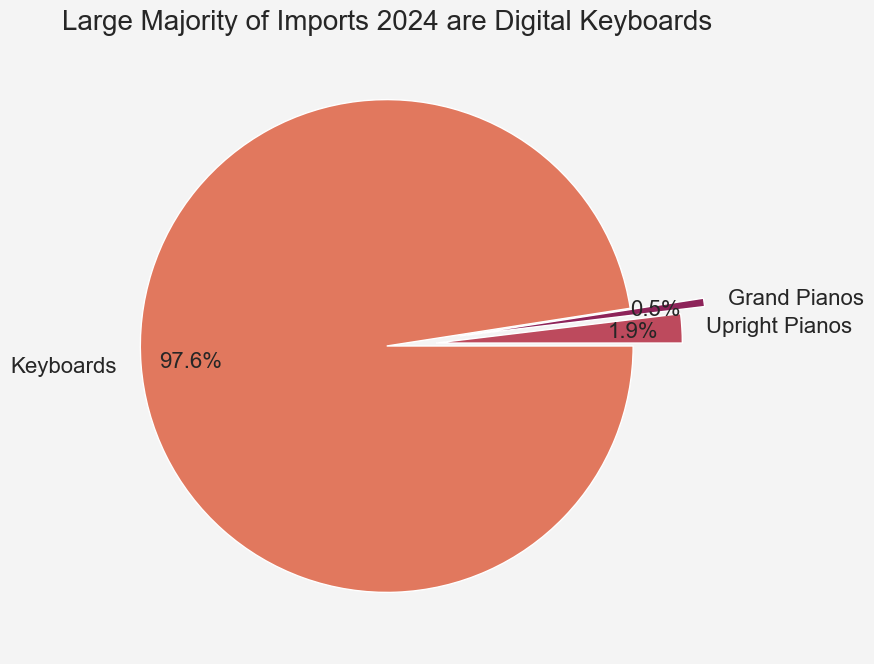

In [18]:
labels = 'Upright Pianos', 'Grand Pianos', 'Keyboards'
pal_ = colors
#plot a pie chart
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 16})
explode = [0.2, 0.3, 0]
plt.pie(imports[24],
        labels=labels,
        colors=pal_, autopct='%1.1f%%',
        pctdistance=0.8, explode=explode, textprops={'size': 'medium'})
plt.title('Large Majority of Imports 2024 are Digital Keyboards', fontdict={'fontsize': 20})

plt.savefig(os.path.join(path, 'Visualizations', 'imp_pie.png'), bbox_inches='tight')
plt.show()

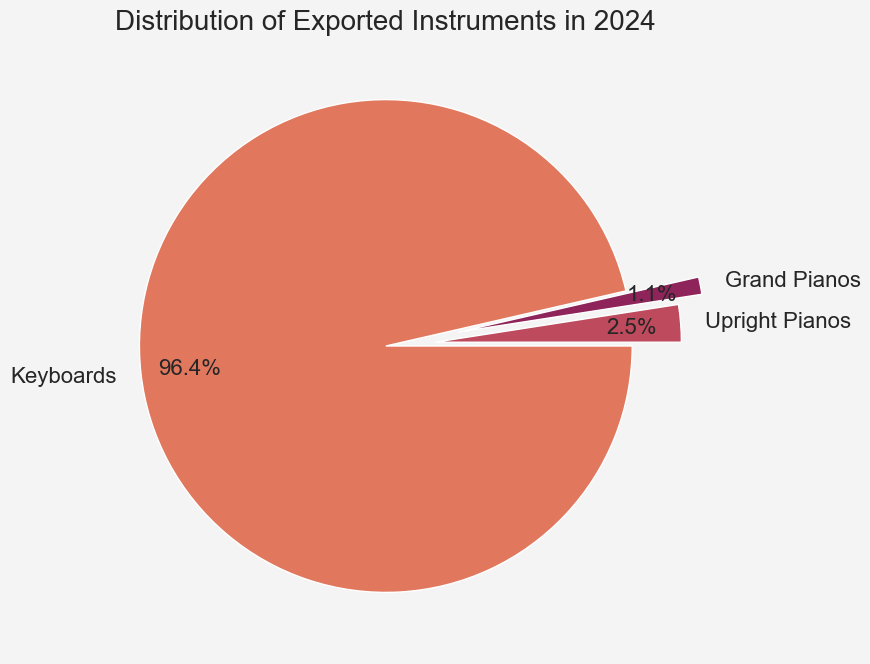

In [150]:
labels = 'Upright Pianos', 'Grand Pianos', 'Keyboards'
pal_ = colors
#plot a pie chart
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 16})
explode = [0.2, 0.3, 0]
plt.pie(exports[24],
        labels=labels,
        colors=pal_, autopct='%1.1f%%',
        pctdistance=0.8, explode=explode, textprops={'size': 'medium'})
plt.title('Distribution of Exported Instruments in 2024', fontdict={'fontsize': 20})
# plt.legend(bbox_to_anchor=(1, 1), loc=2, frameon=False)
plt.show()

In [19]:
# production comparing decade
decade = df2014[df2014['Year'].isin([2014, 2024])]
decade

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,Upright Export Trade Value,Grand Export Trade Value,Keyboard Export Trade Value,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity
14,2014,14068,2317,254469,10658,3907,121177,47895.19,40926.16,231015.81,68931.79,152076.75,141004.64,3.404549,17.663427,0.907835,6.46761,38.924175,1.163625,27201.0,3964.0,74626.0,2563.0
24,2024,6558,1876,336050,5728,2659,225301,21018.70,25245.36,176079.88,35208.41,122108.03,163885.00,3.205047,13.457015,0.523969,6.14672,45.922539,0.727405,18028.0,1336.0,110422.0,1286.0


In [20]:
# bar chart
dec_melt = pd.melt(decade[['Year', 'Grand Prod Quantity', 'Upright Prod Quantity']], ['Year'])
dec_melt.rename(columns={'variable': 'Instrument', 'value':'Quantity'}, inplace=True)
dec_melt['Instrument'] = dec_melt['Instrument'].replace('Grand Prod Quantity', 'Grand Pianos')
dec_melt['Instrument'] = dec_melt['Instrument'].replace('Upright Prod Quantity', 'Upright Pianos')
dec_melt

,Year,Instrument,Quantity
0,2014,Grand Pianos,2563.0
1,2024,Grand Pianos,1286.0
2,2014,Upright Pianos,3964.0
3,2024,Upright Pianos,1336.0


Text(0.5, 1.0, 'Production of Pianos Halved in a Decade')

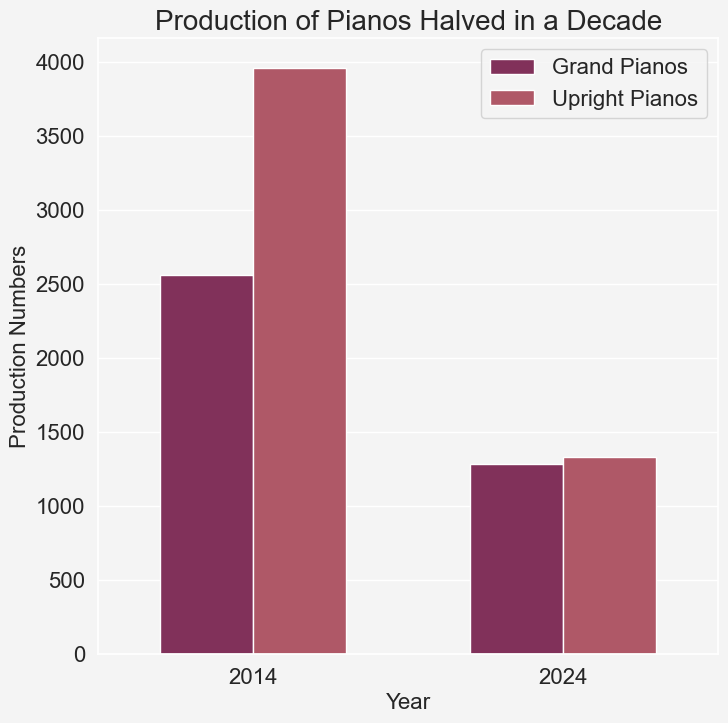

In [21]:
plt.figure(figsize=(8, 8))

clrs = [colors[1], colors[0]]
prod_bar = sns.barplot(data=dec_melt, x='Year', y='Quantity', hue='Instrument', width=0.6, palette=clrs)
prod_bar.tick_params(labelsize=16)
prod_bar.set_xlabel('Year', fontsize=16)
prod_bar.set_ylabel('Production Numbers', fontsize=16)
prod_bar.legend(fontsize=16, title_fontsize=16)
prod_bar.set_title("Production of Pianos Halved in a Decade", fontsize=20)

In [22]:
# save figure
prod_bar.figure.savefig(os.path.join(path, 'Visualizations', 'prod_bar.png'), bbox_inches='tight')

## Production from 2014 on

In [23]:
# production over time
df_prod = pd.melt(df2014[['Year', 'Upright Prod Quantity', 'Grand Prod Quantity']], ['Year'])

df_prod.rename(columns={'value': 'Quantity', 'variable': 'Instrument'}, inplace=True)
df_prod['Instrument'] = df_prod['Instrument'].replace('Grand Prod Quantity', 'Grand Pianos')
df_prod['Instrument'] = df_prod['Instrument'].replace('Upright Prod Quantity', 'Upright Pianos')

Text(0.5, 1.0, 'Production Falls Steeply after 2022')

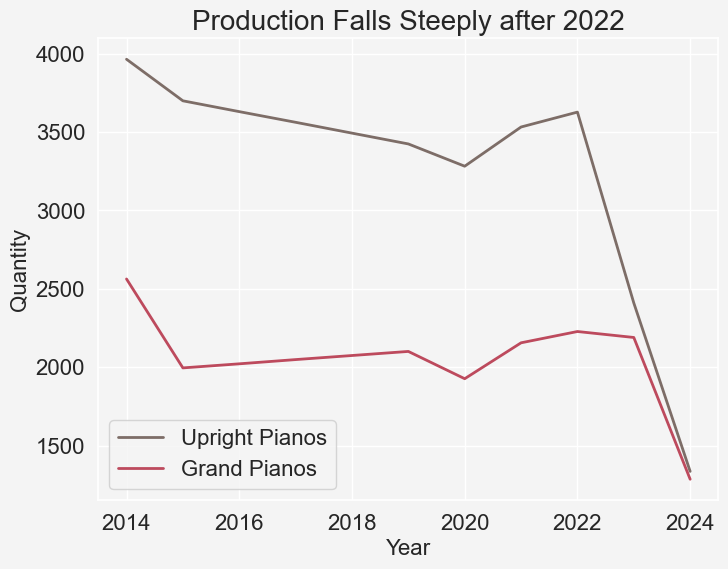

In [24]:
plt.figure(figsize=(8, 6))
clrs = [colors[3], colors[0]]
prod_lines = sns.lineplot(data=df_prod, x='Year', y='Quantity', hue='Instrument', palette=clrs, linewidth=2)
#prod_lines.set(title='Production of Acoustic Pianos in Germany')

prod_lines.tick_params(labelsize=16)
prod_lines.set_xlabel('Year', fontsize=16)
prod_lines.set_ylabel('Quantity', fontsize=16)
prod_lines.legend(fontsize=16, title_fontsize=16)
prod_lines.set_title("Production Falls Steeply after 2022", fontsize=20)

In [25]:
# save figure
prod_lines.figure.savefig(os.path.join(path, 'Visualizations', 'prod_lines.png'), bbox_inches='tight')

<Axes: xlabel='Year', ylabel='Prod Grand Euro'>

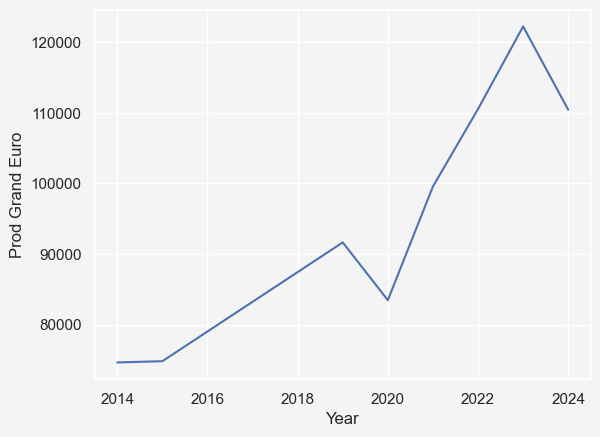

In [26]:
# production value in 1000 DE GRANDS
sns.lineplot(data=df2014, x='Year', y='Prod Grand Euro')

<Axes: xlabel='Year', ylabel='Prod Upright Euro'>

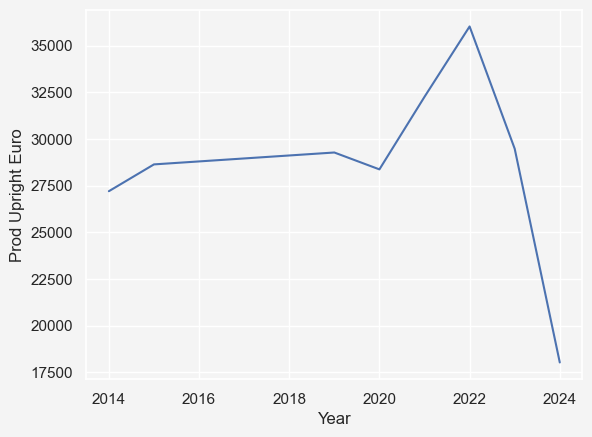

In [27]:
# production value in 1000 DE UPRIGHT
sns.lineplot(data=df2014, x='Year', y='Prod Upright Euro')

In [28]:
# price per grand in euro
df2014['Grand Prod Price'] = df2014['Prod Grand Euro']/df2014['Grand Prod Quantity']*1000
df2014['Upright Prod Price'] = df2014['Prod Upright Euro']/df2014['Upright Prod Quantity']*1000

df2014[['Year', 'Grand Prod Quantity','Grand Prod Price', 'Upright Prod Price']]

,Year,Grand Prod Quantity,Grand Prod Price,Upright Prod Price
14,2014,2563.0,29116.660164,6862.008073
15,2015,1996.0,37476.953908,7741.822114
16,2016,2022.0,39075.296736,7932.851240
17,2017,2049.0,40613.225964,8129.000561
18,2018,2075.0,42131.445783,8335.170341
19,2019,2101.0,43612.089481,8549.649533
20,2020,1927.0,43305.656461,8644.119439
21,2021,2156.0,46171.150278,9132.785957
22,2022,2228.0,49604.578097,9932.726771
23,2023,2190.0,55806.849315,12231.120332


In [29]:
# line chart grands
grand_melt = pd.melt(df2014[['Year', 'Grand Prod Quantity', 'Grand Prod Price']], ['Year'])
grand_melt.rename(columns={'variable': 'Variable', 'value':'Value'}, inplace=True)

[Text(0.5, 1.0, 'Production Numbers vs Price')]

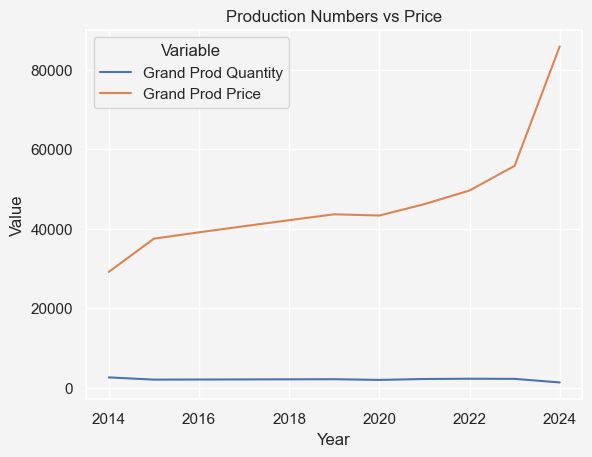

In [30]:
#plt.figure(figsize=(8, 8))
# clrs = [colors[0], colors[1]]
grand_lines = sns.lineplot(data=grand_melt, x='Year', y='Value', hue='Variable')
grand_lines.set(title='Production Numbers vs Price')

Trend is more visible if value only * 100, but reduces clarity for chart.

In [31]:
# line chart grands
up_melt = pd.melt(df2014[['Year', 'Upright Prod Quantity', 'Upright Prod Price']], ['Year'])
up_melt.rename(columns={'variable': 'Variable', 'value':'Value'}, inplace=True)

[Text(0.5, 1.0, 'Production Numbers vs Price for Uprights')]

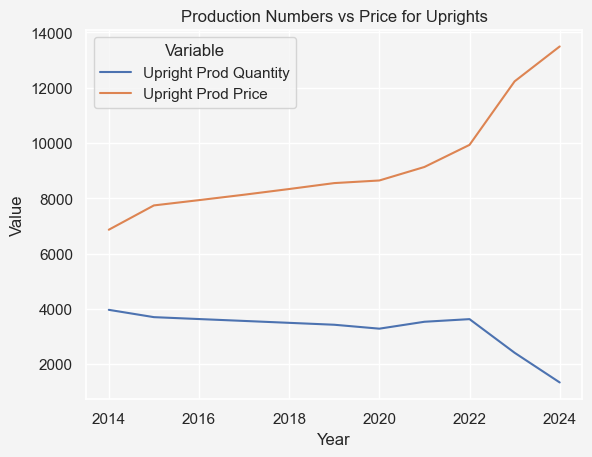

In [32]:
#plt.figure(figsize=(8, 8))
# clrs = [colors[0], colors[1]]
up_lines = sns.lineplot(data=up_melt, x='Year', y='Value', hue='Variable')
up_lines.set(title='Production Numbers vs Price for Uprights')

Visible contrary trend lines, indicating strong negative correlation. Correlation test to follow.

In [33]:
# line chart prices for both
pp_melt = pd.melt(df2014[['Year', 'Upright Prod Price', 'Grand Prod Price']], ['Year'])
pp_melt.rename(columns={'variable': 'Instrument', 'value':'Value in Euros'}, inplace=True)
pp_melt['Instrument'] = pp_melt['Instrument'].replace('Grand Prod Price', 'Grand Piano')
pp_melt['Instrument'] = pp_melt['Instrument'].replace('Upright Prod Price', 'Upright Piano')

Text(0.5, 1.0, 'Value of Grand Pianos Rise Exponentially')

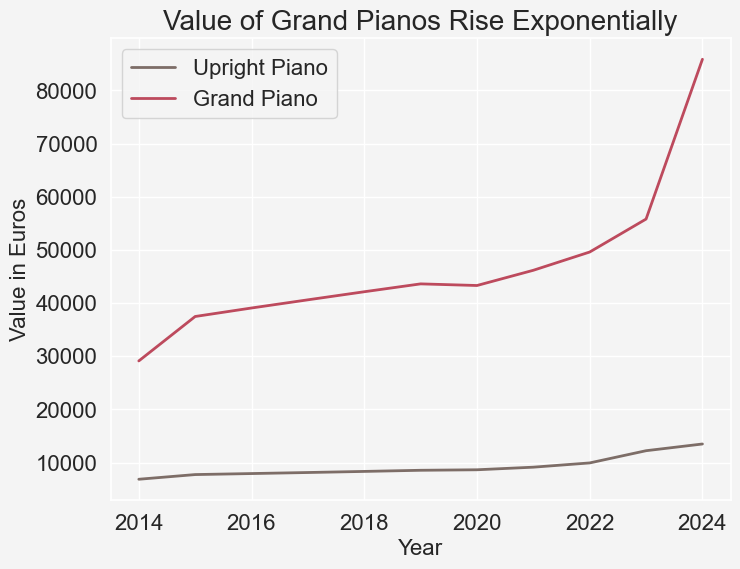

In [34]:
plt.figure(figsize=(8, 6))
clrs = [colors[3], colors[0]]
pp_lines = sns.lineplot(data=pp_melt, x='Year', y='Value in Euros', hue='Instrument', palette=clrs, linewidth=2)
#pp_lines.set(title='Value of Grand Pianos Rise Exponentially')

pp_lines.tick_params(labelsize=16)
pp_lines.set_xlabel('Year', fontsize=16)
pp_lines.set_ylabel('Value in Euros', fontsize=16)
pp_lines.legend(fontsize=16, title_fontsize=16)
pp_lines.set_title("Value of Grand Pianos Rise Exponentially", fontsize=20)

In [35]:
# save figure
pp_lines.figure.savefig(os.path.join(path, 'Visualizations', 'pp_lines.png'), bbox_inches='tight')

## Hypothesis
As production decreases, value (or price) increases.
•	H₀: As domestic piano production decreases, prices remain the same or decreases.
•	H₁: Decreasing piano production is associated with increasing prices.

In [36]:
# corr prod numbers and price
df2014[['Grand Prod Price', 'Grand Prod Quantity']].corr()

,Grand Prod Price,Grand Prod Quantity
Grand Prod Price,1.000000,-0.810833
Grand Prod Quantity,-0.810833,1.000000


In [37]:
# corr prod numbers and price
df2014[['Upright Prod Price', 'Upright Prod Quantity']].corr()

,Upright Prod Price,Upright Prod Quantity
Upright Prod Price,1.000000,-0.931995
Upright Prod Quantity,-0.931995,1.000000


In both instruments, there is a strong negative correlation between production numbers and average value per instrument. The less instruments Germany manufactures, the more expensive they get.

<Axes: xlabel='Upright Prod Quantity', ylabel='Upright Prod Price'>

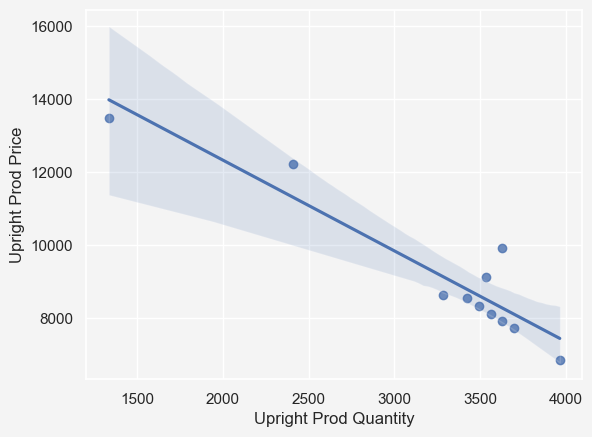

In [38]:
sns.regplot(data=df2014, x='Upright Prod Quantity', y='Upright Prod Price')

## Imports of instruments

In [39]:
# viz line chart keyboard imports upright imports
dfl = pd.melt(df2014[['Year', 'Upright Import Quantity', 'Keyboard Import Quantity', 'Grand Import Quantity']], ['Year'])
dfl

,Year,variable,value
0,2014,Upright Import Quantity,14068
1,2015,Upright Import Quantity,12908
2,2016,Upright Import Quantity,14083
3,2017,Upright Import Quantity,11760
4,2018,Upright Import Quantity,12084
5,2019,Upright Import Quantity,14320
6,2020,Upright Import Quantity,11537
7,2021,Upright Import Quantity,13993
8,2022,Upright Import Quantity,14680
9,2023,Upright Import Quantity,9878


In [40]:
# relabel df
dfl.rename(columns={'value': 'Quantity', 'variable': 'Instrument'}, inplace=True)
dfl['Instrument'] = dfl['Instrument'].replace('Upright Import Quantity', 'Upright Pianos')
dfl['Instrument'] = dfl['Instrument'].replace('Grand Import Quantity', 'Grand Pianos')
dfl['Instrument'] = dfl['Instrument'].replace('Keyboard Import Quantity', 'Keyboards')

[Text(0.5, 1.0, 'Keyboard Imports Grow and Dominate over last Decade')]

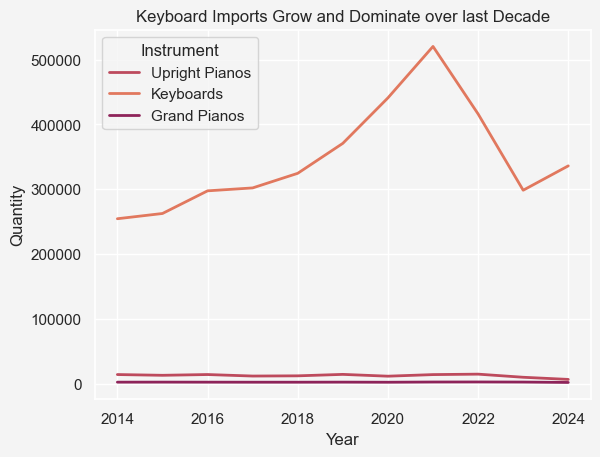

In [41]:
#plt.figure(figsize=(8, 8))
clrs = [colors[0], colors[2], colors[1]]

# imports of keyboards peak during Pandemic
import_line = sns.lineplot(data=dfl, x='Year', y='Quantity', hue='Instrument', palette=clrs, linewidth=2)
import_line.set(title='Keyboard Imports Grow and Dominate over last Decade')

Acoustic piano quantities stay low while keyboards grow and fluctuate. Peak of keyboard imports in 2020 in midst of pandemic.
Affordability may be a factor.

## Export of instruments 

In [42]:
# view export correlation 
exp_q = pd.melt(df2014[['Year', 'Upright Export Quantity', 'Keyboard Export Quantity', 'Grand Export Quantity']], ['Year'])

<Axes: xlabel='Year', ylabel='value'>

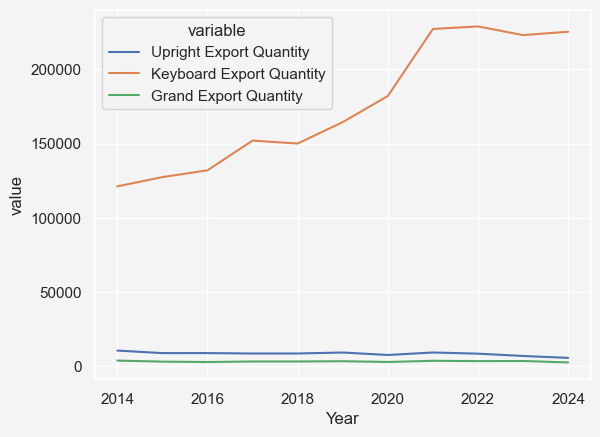

In [43]:
sns.lineplot(data=exp_q, x='Year', y='value', hue='variable')

Keyboard exports increasing while acoustic stays low. 

In [44]:
# export trade values
export_tv = list()
for col in df2014.columns:
    if 'Export Trade' in col:
        export_tv.append(col)
export_tv.append('Year')

In [45]:
dfl1 = pd.melt(df2014[export_tv], ['Year'])

<Axes: xlabel='Year', ylabel='value'>

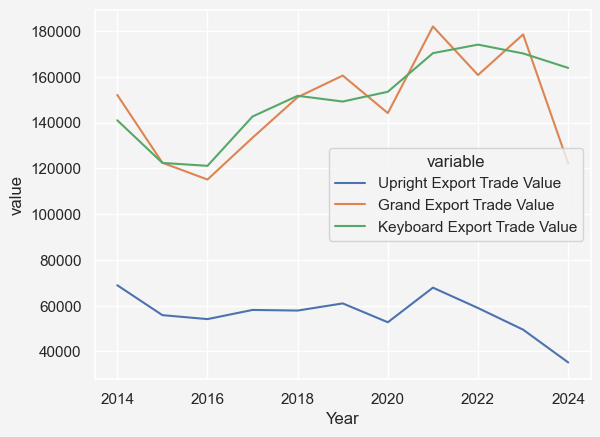

In [46]:
sns.lineplot(data=dfl1, x='Year', y='value', hue='variable')

Grand export values comparable to keyboard exports, although quantity is low. While reducing production, grand piano market stays competitive by increasing price.

In [47]:
# combine acoustic instruments
df2014['Acoustic Export Trade Value'] = df2014['Grand Export Trade Value'] + df2014['Upright Export Trade Value']

In [48]:
# compare trade values of only acoustics and keyboards
dfl1a = pd.melt(df2014[['Year', 'Acoustic Export Trade Value', 'Keyboard Export Trade Value']], ['Year'])
dfl1a.rename(columns={'value': 'Trade Value', 'variable': 'Instrument'}, inplace=True)

[Text(0.5, 1.0, 'Export Trade Values for Acoustic Pianos and Keyboards Stay Competitive')]

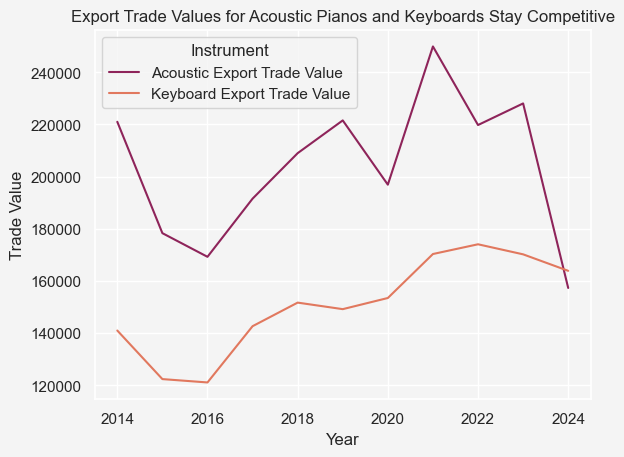

In [49]:
#plt.figure(figsize=(8, 8))
clrs = [colors[1], colors[2]]

sns.lineplot(data=dfl1a, x='Year', y='Trade Value', hue='Instrument', palette=clrs).set(title='Export Trade Values for Acoustic Pianos and Keyboards Stay Competitive')

In [50]:
# grand export value vs export quantity, are grands getting more expensive?
df2014[['Grand Export Trade Value', 'Grand Export Quantity']].corr()

,Grand Export Trade Value,Grand Export Quantity
Grand Export Trade Value,1.000000,0.780142
Grand Export Quantity,0.780142,1.000000


Strong positive correlation shows that as Germany exports more grands, values are also increasing.

## Observe and compare prices

In [52]:
# compare import and export prices of grand pianos
grand_price = df2014[['Year', 'Grand Export Price', 'Grand Import Price']]
dfl4 = pd.melt(grand_price, ['Year'])

<Axes: xlabel='Year', ylabel='value'>

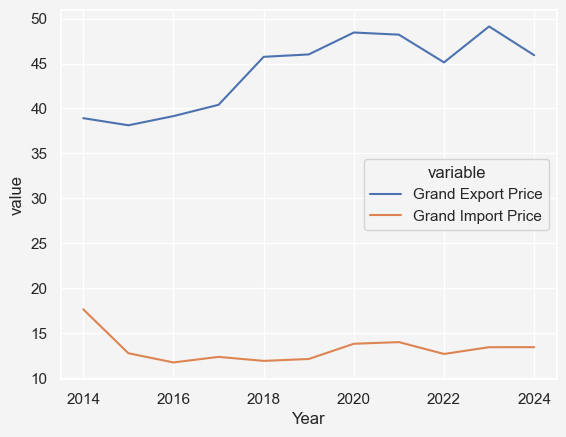

In [53]:
sns.lineplot(data=dfl4, x='Year', y='value', hue='variable')

German pianos seem to be significantly more expensive than imported pianos.

## Calculate Net Imports

In [54]:
# new columns for net imports
df2014['Upright Net Imports'] = df2014['Upright Import Quantity'] - df2014['Upright Export Quantity']
df2014['Grand Net Imports'] = df2014['Grand Import Quantity'] - df2014['Grand Export Quantity']
df2014['Keyboard Net Imports'] = df2014['Keyboard Import Quantity'] - df2014['Keyboard Export Quantity']

In [55]:
df2014[['Year', 'Upright Net Imports', 'Grand Net Imports', 'Keyboard Net Imports']]

,Year,Upright Net Imports,Grand Net Imports,Keyboard Net Imports
14,2014,3410,-1590,133292
15,2015,3954,-825,135136
16,2016,5125,-623,165503
17,2017,3078,-1042,150014
18,2018,3393,-1046,174534
19,2019,4973,-1126,206364
20,2020,3851,-767,258897
21,2021,4629,-1233,293135
22,2022,6111,-939,187290
23,2023,2863,-1162,75432


Negative net imports indicate that DE exported more products than import, implying high number of domestic production.

<Axes: xlabel='Year', ylabel='Keyboard Net Imports'>

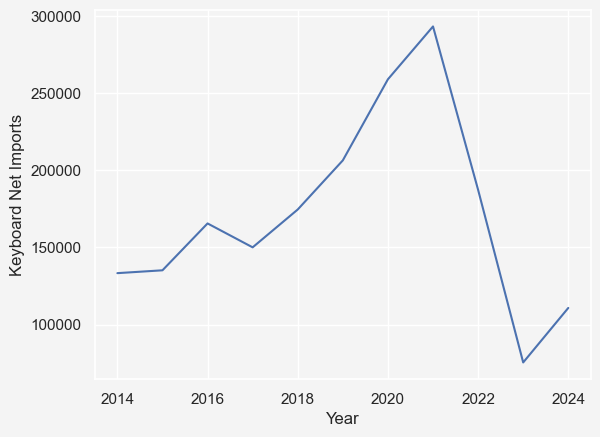

In [56]:
# Net import trend line for keyboards
sns.lineplot(data=df2014, x='Year', y='Keyboard Net Imports')

Keyboard imports rise after 2017, peaking during the pandemic and dropping to lowest point in 2023.

<Axes: xlabel='Year', ylabel='value'>

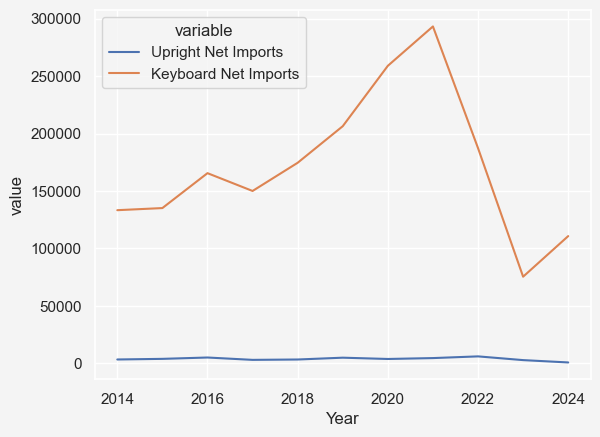

In [57]:
# compare net imports of uprights and keyboards
net_imp = df2014[['Year', 'Upright Net Imports', 'Keyboard Net Imports']]
dfl5 = pd.melt(net_imp, ['Year'])

sns.lineplot(data=dfl5, x='Year', y='value', hue='variable')

## Calculate domestic market size for uprights and grands

In [58]:
# upright and grand
df2014['Upright Market'] = df2014['Upright Prod Quantity'] + df2014['Upright Net Imports']
df2014['Grand Market'] = df2014['Grand Prod Quantity'] + df2014['Grand Net Imports']
df2014[['Year','Grand Market', 'Upright Market']]

,Year,Grand Market,Upright Market
14,2014,973.0,7374.0
15,2015,1171.0,7653.0
16,2016,1399.0,8755.0
17,2017,1007.0,6640.0
18,2018,1029.0,6886.0
19,2019,975.0,8397.0
20,2020,1160.0,7133.0
21,2021,923.0,8161.0
22,2022,1289.0,9738.0
23,2023,1028.0,5273.0


In [59]:
# view market size of acoustic instruments
market_de = df2014[['Year', 'Upright Market', 'Grand Market', 'Keyboard Net Imports']].copy()
dfl6 = pd.melt(market_de, ['Year'])

dfl6.rename(columns={'value': 'Quantity', 'variable': 'Instrument'}, inplace=True)
dfl6['Instrument'] = dfl6['Instrument'].replace('Grand Market', 'Grand Pianos')
dfl6['Instrument'] = dfl6['Instrument'].replace('Upright Market', 'Upright Pianos')
dfl6['Instrument'] = dfl6['Instrument'].replace('Keyboard Net Imports', 'Keyboards')


Text(0.5, 1.0, 'Keyboard Demand Grows and Peaks During Pandemic')

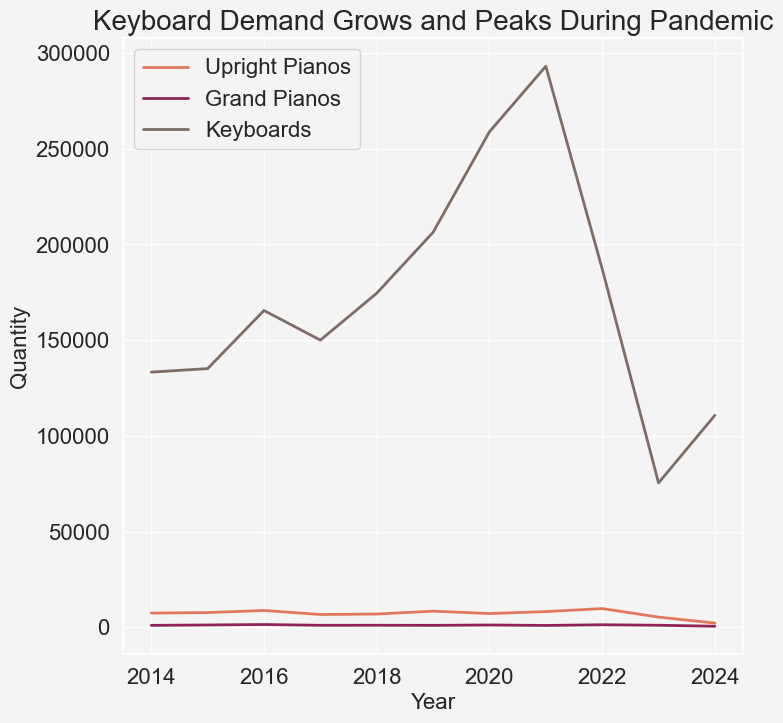

In [60]:
plt.figure(figsize=(8, 8))
clrs = [colors[2], colors[1], colors[3]]

# net import of keyboards and market size
market_line = sns.lineplot(data=dfl6, x='Year', y='Quantity', hue='Instrument', palette=clrs, linewidth=2)

market_line.tick_params(labelsize=16)
market_line.set_xlabel('Year', fontsize=16)
market_line.set_ylabel('Quantity', fontsize=16)
market_line.legend(fontsize=16, title_fontsize=16)
market_line.set_title("Keyboard Demand Grows and Peaks During Pandemic", fontsize=20)

In [61]:
market_line.figure.savefig(os.path.join(path, 'Visualizations', 'market_line.png'), bbox_inches='tight')

In [62]:
# percentages within with market_de df
market_de['total'] = market_de['Upright Market'] + market_de['Grand Market']
market_de['Upright Percentage'] = market_de['Upright Market']/market_de['total']*100
market_de['Grand Percentage'] = market_de['Grand Market']/market_de['total']*100
market_de

,Year,Upright Market,Grand Market,Keyboard Net Imports,total,Upright Percentage,Grand Percentage
14,2014,7374.0,973.0,133292,8347.0,88.343117,11.656883
15,2015,7653.0,1171.0,135136,8824.0,86.729374,13.270626
16,2016,8755.0,1399.0,165503,10154.0,86.222178,13.777822
17,2017,6640.0,1007.0,150014,7647.0,86.831437,13.168563
18,2018,6886.0,1029.0,174534,7915.0,86.999368,13.000632
19,2019,8397.0,975.0,206364,9372.0,89.596671,10.403329
20,2020,7133.0,1160.0,258897,8293.0,86.012300,13.987700
21,2021,8161.0,923.0,293135,9084.0,89.839278,10.160722
22,2022,9738.0,1289.0,187290,11027.0,88.310511,11.689489
23,2023,5273.0,1028.0,75432,6301.0,83.685129,16.314871


<Axes: xlabel='Year', ylabel='value'>

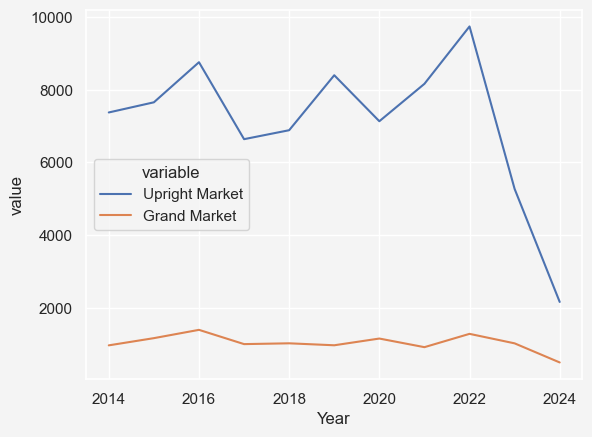

In [63]:
# compare markets of uprights and grands
acoustic_mark = df2014[['Year', 'Upright Market', 'Grand Market']]
dfl6 = pd.melt(acoustic_mark, ['Year'])

sns.lineplot(data=dfl6, x='Year', y='value', hue='variable')

## Growth

In [64]:
# calculate growth of keyboard net, market grand and market upright
# (curr year - prev year)/prev year
df2014['Upright Growth'] = (df2014['Upright Market'] - df2014['Upright Market'].shift(1))/ df2014['Upright Market'].shift(1)
df2014['Grand Growth'] = (df2014['Grand Market'] - df2014['Grand Market'].shift(1))/ df2014['Grand Market'].shift(1)
df2014['Keyboard Growth'] = (df2014['Keyboard Net Imports'] - df2014['Keyboard Net Imports'].shift(1))/ df2014['Keyboard Net Imports'].shift(1)
df2014.head()

,Year,Upright Import Quantity,Grand Import Quantity,Keyboard Import Quantity,Upright Export Quantity,Grand Export Quantity,Keyboard Export Quantity,Upright Import Trade Value,Grand Import Trade Value,Keyboard Import Trade Value,Upright Export Trade Value,Grand Export Trade Value,Keyboard Export Trade Value,Upright Import Price,Grand Import Price,Keyboard Import Price,Upright Export Price,Grand Export Price,Keyboard Export Price,Prod Upright Euro,Upright Prod Quantity,Prod Grand Euro,Grand Prod Quantity,Grand Prod Price,Upright Prod Price,Acoustic Export Trade Value,Upright Net Imports,Grand Net Imports,Keyboard Net Imports,Upright Market,Grand Market,Upright Growth,Grand Growth,Keyboard Growth
14,2014,14068,2317,254469,10658,3907,121177,47895.19,40926.16,231015.81,68931.79,152076.75,141004.64,3.404549,17.663427,0.907835,6.467610,38.924175,1.163625,27201.00,3964.0,74626.00,2563.0,29116.660164,6862.008073,221008.54,3410,-1590,133292,7374.0,973.0,NaN,NaN,NaN
15,2015,12908,2386,262565,8954,3211,127429,40949.44,30494.82,202245.39,55875.48,122446.32,122385.36,3.172408,12.780729,0.770268,6.240281,38.133391,0.960420,28637.00,3699.0,74804.00,1996.0,37476.953908,7741.822114,178321.80,3954,-825,135136,7653.0,1171.0,0.037836,0.203494,0.013834
16,2016,14083,2317,297512,8958,2940,132009,45748.83,27243.08,214669.42,54144.23,115111.86,121101.27,3.248515,11.757911,0.721549,6.044232,39.153694,0.917371,28796.25,3630.0,79010.25,2022.0,39075.296736,7932.851240,169256.09,5125,-623,165503,8755.0,1399.0,0.143996,0.194705,0.224714
17,2017,11760,2259,302030,8682,3301,152016,37993.50,27959.71,229715.28,58150.16,133393.80,142662.47,3.230740,12.377030,0.760571,6.697784,40.410118,0.938470,28955.50,3562.0,83216.50,2049.0,40613.225964,8129.000561,191543.96,3078,-1042,150014,6640.0,1007.0,-0.241576,-0.280200,-0.093587
18,2018,12084,2257,324570,8691,3303,150036,36432.04,26928.79,240739.25,57879.21,151100.79,151701.62,3.014899,11.931232,0.741718,6.659672,45.746530,1.011101,29114.75,3493.0,87422.75,2075.0,42131.445783,8335.170341,208980.00,3393,-1046,174534,6886.0,1029.0,0.037048,0.021847,0.163451


<Axes: xlabel='Year', ylabel='value'>

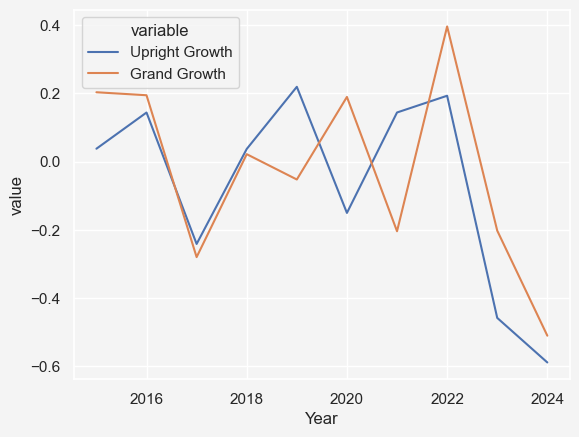

In [65]:
# view market lines again using growth
market_g = df2014[['Year', 'Upright Growth', 'Grand Growth']]
dfl6a = pd.melt(market_g, ['Year'])

sns.lineplot(data=dfl6a, x='Year', y='value', hue='variable')
# not a useful chart

## Hypothesis on Imports vs Production
As imports increase, production decreases.
•	H₀: Digital keyboard imports have no relationship with domestic acoustic piano production.
•	H₁: Increasing digital keyboard imports are associated with declining domestic acoustic piano production.

In [66]:
# correlation of production numbers and keyboard imports

In [67]:
df2014[['Keyboard Import Quantity', 'Upright Prod Quantity']].corr()

,Keyboard Import Quantity,Upright Prod Quantity
Keyboard Import Quantity,1.000000,0.002308
Upright Prod Quantity,0.002308,1.000000


Correlation shows the null hypothesis to be true, therefore we cannot prove that digital keyboard imports are affecting domestic production of uprights.

In [68]:
df2014[['Keyboard Import Quantity', 'Grand Prod Quantity']].corr()

,Keyboard Import Quantity,Grand Prod Quantity
Keyboard Import Quantity,1.000000,-0.080482
Grand Prod Quantity,-0.080482,1.000000


This correlation also cannot prove the hypothesis.

## Market share

In [71]:
# create market share for quantities
market_df = df2014[['Year', 'Upright Market', 'Grand Market', 'Keyboard Net Imports']].copy()
market_df['Total'] = market_df.sum(axis=1)
market_df

,Year,Upright Market,Grand Market,Keyboard Net Imports,Total
14,2014,7374.0,973.0,133292,143653.0
15,2015,7653.0,1171.0,135136,145975.0
16,2016,8755.0,1399.0,165503,177673.0
17,2017,6640.0,1007.0,150014,159678.0
18,2018,6886.0,1029.0,174534,184467.0
19,2019,8397.0,975.0,206364,217755.0
20,2020,7133.0,1160.0,258897,269210.0
21,2021,8161.0,923.0,293135,304240.0
22,2022,9738.0,1289.0,187290,200339.0
23,2023,5273.0,1028.0,75432,83756.0


In [72]:
market_df['Upright Share'] = market_df['Upright Market']/ market_df['Total']
market_df['Grand Share'] = market_df['Grand Market']/ market_df['Total']
market_df['Keyboard Share'] = market_df['Keyboard Net Imports']/ market_df['Total']

In [73]:
market_df

,Year,Upright Market,Grand Market,Keyboard Net Imports,Total,Upright Share,Grand Share,Keyboard Share
14,2014,7374.0,973.0,133292,143653.0,0.051332,0.006773,0.927875
15,2015,7653.0,1171.0,135136,145975.0,0.052427,0.008022,0.925748
16,2016,8755.0,1399.0,165503,177673.0,0.049276,0.007874,0.931503
17,2017,6640.0,1007.0,150014,159678.0,0.041584,0.006306,0.939478
18,2018,6886.0,1029.0,174534,184467.0,0.037329,0.005578,0.946153
19,2019,8397.0,975.0,206364,217755.0,0.038562,0.004478,0.947689
20,2020,7133.0,1160.0,258897,269210.0,0.026496,0.004309,0.961692
21,2021,8161.0,923.0,293135,304240.0,0.026824,0.003034,0.963499
22,2022,9738.0,1289.0,187290,200339.0,0.048608,0.006434,0.934865
23,2023,5273.0,1028.0,75432,83756.0,0.062957,0.012274,0.900616


Highest share of keyboards in 2020 and 2021. Highest Upright share in 2011, lowest in 2024. Grands stay below 1% after 2014, only going above once in 2023.  How does a stacked chart look? Trend seems to stay the same?

In [74]:
# pie chart of 2024 market share
market_2024 = market_df[['Upright Market', 'Grand Market', 'Keyboard Net Imports']][market_df['Year']==2024]
market_t = market_2024.T
market_t

,24
Upright Market,2166.0
Grand Market,503.0
Keyboard Net Imports,110749.0


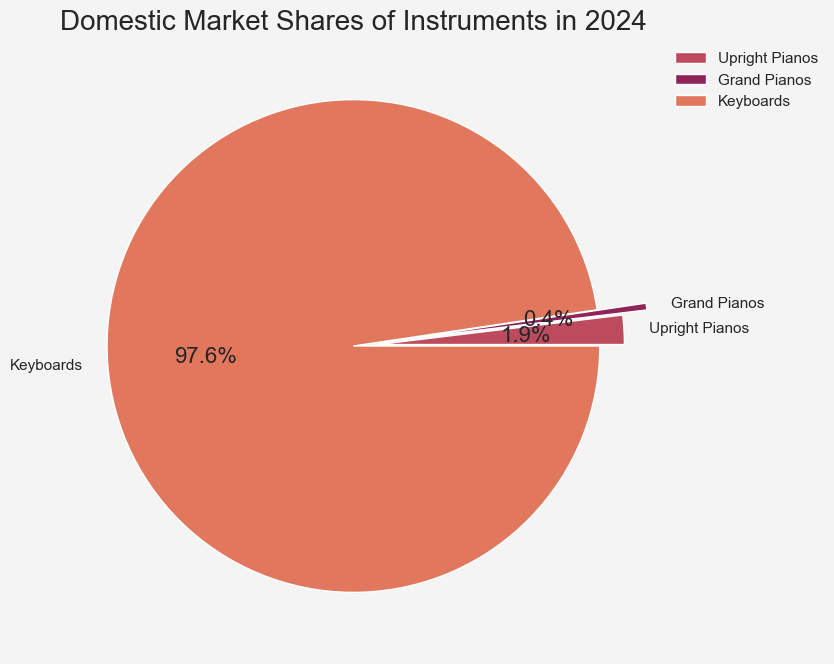

In [75]:
labels = 'Upright Pianos', 'Grand Pianos', 'Keyboards'
pal_ = colors[:3]
#plot a pie chart
plt.figure(figsize=(8, 8))
#plt.rcParams.update({'font.size': 16})
explode = [0.1, 0.2, 0]
plt.pie(market_t[24],
        labels=labels,
        colors=pal_, autopct='%1.1f%%',
        pctdistance=0.6, explode=explode)
plt.title('Domestic Market Shares of Instruments in 2024', fontdict={'fontsize': 20})
plt.legend(bbox_to_anchor=(1, 1), loc=2, frameon=False)
plt.show()

## Export Ratio

In [76]:
# create export ratio
df2014['Upright Ratio'] = df2014['Upright Export Quantity']/df2014['Upright Import Quantity']
df2014['Grand Ratio'] = df2014['Grand Export Quantity']/df2014['Grand Import Quantity']
df2014['Keyboard Ratio'] = df2014['Keyboard Export Quantity']/df2014['Keyboard Import Quantity']

In [77]:
df2014[['Upright Ratio', 'Grand Ratio', 'Keyboard Ratio']]

,Upright Ratio,Grand Ratio,Keyboard Ratio
14,0.757606,1.686232,0.476196
15,0.693678,1.345767,0.485324
16,0.636086,1.268882,0.443710
17,0.738265,1.461266,0.503314
18,0.719215,1.463447,0.462261
19,0.652723,1.476513,0.443491
20,0.666204,1.347373,0.412856
21,0.669192,1.485051,0.436608
22,0.583719,1.357851,0.549948
23,0.710164,1.470065,0.747270


In [78]:
df2014[['Upright Ratio', 'Grand Ratio', 'Keyboard Ratio']].mean()

Upright Ratio     0.700026
Grand Ratio       1.434529
Keyboard Ratio    0.511947
dtype: float64

<Axes: xlabel='Year', ylabel='value'>

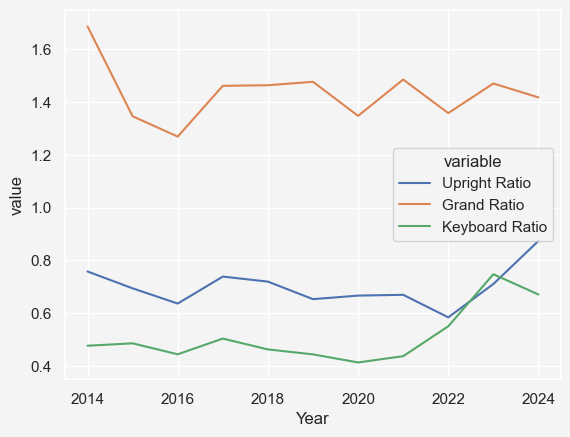

In [79]:
# chart over time
ratio_de = df2014[['Year', 'Upright Ratio', 'Grand Ratio', 'Keyboard Ratio']]
dfl7 = pd.melt(ratio_de, ['Year'])

sns.lineplot(data=dfl7, x='Year', y='value', hue='variable')

For upright and keyboards, around half of instruments are used for domestic consumption. In contrast, the Grand Ratio is 1.4, indicating strong domestic production and export.

## Domestic demand for pianos total

In [80]:
df2014.columns

Index(['Year', 'Upright Import Quantity', 'Grand Import Quantity',
       'Keyboard Import Quantity', 'Upright Export Quantity',
       'Grand Export Quantity', 'Keyboard Export Quantity',
       'Upright Import Trade Value', 'Grand Import Trade Value',
       'Keyboard Import Trade Value', 'Upright Export Trade Value',
       'Grand Export Trade Value', 'Keyboard Export Trade Value',
       'Upright Import Price', 'Grand Import Price', 'Keyboard Import Price',
       'Upright Export Price', 'Grand Export Price', 'Keyboard Export Price',
       'Prod Upright Euro', 'Upright Prod Quantity', 'Prod Grand Euro',
       'Grand Prod Quantity', 'Grand Prod Price', 'Upright Prod Price',
       'Acoustic Export Trade Value', 'Upright Net Imports',
       'Grand Net Imports', 'Keyboard Net Imports', 'Upright Market',
       'Grand Market', 'Upright Growth', 'Grand Growth', 'Keyboard Growth',
       'Upright Ratio', 'Grand Ratio', 'Keyboard Ratio'],
      dtype='object')

In [81]:
# total net imports and market size by year
df2014['Piano Market Q'] = df2014['Grand Market']+df2014['Upright Market']+df2014['Keyboard Net Imports']
df2014[['Year', 'Piano Market Q']]

,Year,Piano Market Q
14,2014,141639.0
15,2015,143960.0
16,2016,175657.0
17,2017,157661.0
18,2018,182449.0
19,2019,215736.0
20,2020,267190.0
21,2021,302219.0
22,2022,198317.0
23,2023,81733.0


<Axes: xlabel='Year', ylabel='Piano Market Q'>

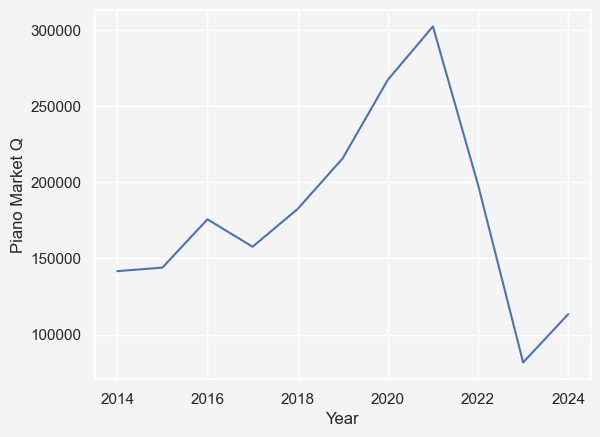

In [82]:
# graph domestic demand
sns.lineplot(data=df2014, x='Year', y='Piano Market Q')

In [83]:
# total value of Germany's production
df2014['Acoustic Value'] = df2014['Prod Upright Euro'] + df2014['Prod Grand Euro']
df2014[['Year', 'Acoustic Value']]

,Year,Acoustic Value
14,2014,101827.0
15,2015,103441.0
16,2016,107806.5
17,2017,112172.0
18,2018,116537.5
19,2019,120903.0
20,2020,111820.0
21,2021,131802.0
22,2022,146545.0
23,2023,151694.0
